# **Código Python: Unidade 2**

#Instalando a Biblioteca para análise de Sobrevivência

#**Exemplo: Dados de Hepatite (Gregory et al. 1976)**

##Cenário: Estudo clínico para avaliar o tempo de sobrevivência de pacientes com hepatite viral aguda submetidos a dois tipos de tratamento (A: Controle e B: Esteróide)

###Passo 1: Configurar o ambiente

Certifique-se de que você tem a biblioteca lifelines instalada. Caso contrário, use o seguinte comando:

In [1]:
pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 5.3 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=ff547b821dcfe1aac7903f0e4beb0e574bf4be0d3144348aa88d814dba0985fd
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


###Passo 2: Código *Python*

Importando as funções

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines import NelsonAalenFitter
from lifelines.statistics import logrank_test
from scipy.stats import gaussian_kde

###Inserir dados e separar por grupos

In [3]:

# Simulação de dados
data = pd.DataFrame({
    "time": [1, 2, 1, 1, 3, 3, 3, 1, 11, 5, 5, 4, 5, 7, 8, 16, 16, 10, 10, 16, 16, 16, 12, 16, 16, 16, 16, 16, 16],
    "event": [0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 1 = evento ocorreu, 0 = censurado
    "group": ["A", "A", "B", "B", "A", "A", "A", "A", "B", "B", "A", "A", "B", "B", "B", "B", "A", "A", "B", "B", "A", "A", "A", "B", "B", "A", "B", "A", "A"]
})

# Separação dos grupos
group_a = data[data["group"] == "A"]
group_b = data[data["group"] == "B"]
print(group_a)
#print(group_b)
print(data)

    time  event group
0      1      0     A
1      2      0     A
4      3      1     A
5      3      1     A
6      3      0     A
7      1      1     A
10     5      0     A
11     4      0     A
16    16      0     A
17    10      1     A
20    16      0     A
21    16      0     A
22    12      0     A
25    16      0     A
27    16      0     A
28    16      0     A
    time  event group
0      1      0     A
1      2      0     A
2      1      1     B
3      1      1     B
4      3      1     A
5      3      1     A
6      3      0     A
7      1      1     A
8     11      0     B
9      5      0     B
10     5      0     A
11     4      0     A
12     5      1     B
13     7      1     B
14     8      1     B
15    16      0     B
16    16      0     A
17    10      1     A
18    10      0     B
19    16      0     B
20    16      0     A
21    16      0     A
22    12      0     A
23    16      0     B
24    16      0     B
25    16      0     A
26    16      0     B
27    16  

###Construindo o quadro de sobrevivência

In [4]:
# Adicionar uma coluna indicando censura
data["Censura"] = data["event"].apply(lambda x: "Não" if x == 1 else "Sim")

# Renomear colunas para exibição clara
data.rename(columns={
    "Grupo": "group",
    "Tempo_Sobrevivencia": "time",
    "Evento": "event (1 = Ocorrido, 0 = Censurado)",
    "Censura": "Censurado"
}, inplace=True)

# Exibir o quadro final
print(data)


    time  event group Censurado
0      1      0     A       Sim
1      2      0     A       Sim
2      1      1     B       Não
3      1      1     B       Não
4      3      1     A       Não
5      3      1     A       Não
6      3      0     A       Sim
7      1      1     A       Não
8     11      0     B       Sim
9      5      0     B       Sim
10     5      0     A       Sim
11     4      0     A       Sim
12     5      1     B       Não
13     7      1     B       Não
14     8      1     B       Não
15    16      0     B       Sim
16    16      0     A       Sim
17    10      1     A       Não
18    10      0     B       Sim
19    16      0     B       Sim
20    16      0     A       Sim
21    16      0     A       Sim
22    12      0     A       Sim
23    16      0     B       Sim
24    16      0     B       Sim
25    16      0     A       Sim
26    16      0     B       Sim
27    16      0     A       Sim
28    16      0     A       Sim


###Estimação por Kaplan-Meier

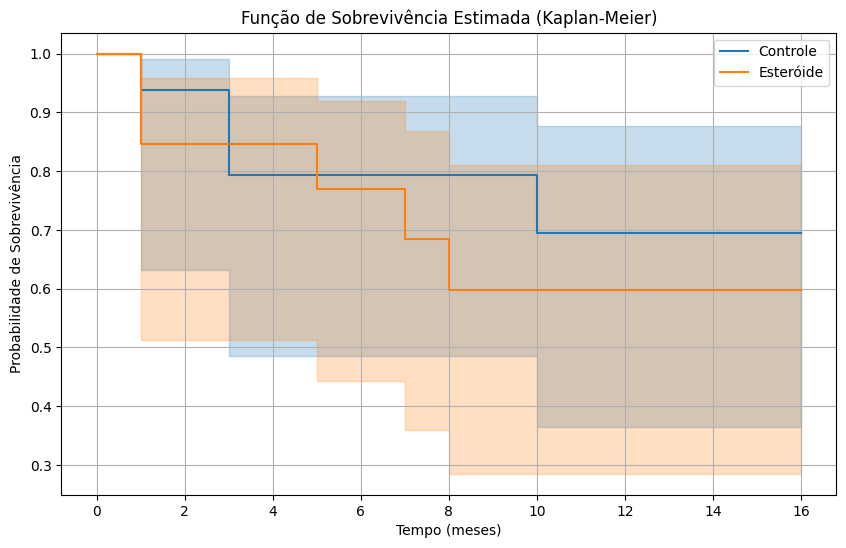

In [5]:
# Estimador de Kaplan-Meier para cada grupo
kmf_a = KaplanMeierFitter()
kmf_b = KaplanMeierFitter()

# Ajustar os modelos
kmf_a.fit(durations=group_a["time"], event_observed=group_a["event"], label="Controle")
kmf_b.fit(durations=group_b["time"], event_observed=group_b["event"], label="Esteróide")

# Visualização
plt.figure(figsize=(10, 6))
kmf_a.plot_survival_function(ci_show=True)
kmf_b.plot_survival_function(ci_show=True)
plt.title("Função de Sobrevivência Estimada (Kaplan-Meier)")
plt.xlabel("Tempo (meses)")
plt.ylabel("Probabilidade de Sobrevivência")
plt.grid(True)
plt.show()

In [ ]:
# Ajustar os modelos
kmf_a.fit(durations=group_a["time"], event_observed=group_a["event"], label="Controle")
print(kmf_a.survival_function_)
kmf_b.fit(durations=group_b["time"], event_observed=group_b["event"], label="Esteróide")
print(kmf_b.survival_function_)

          Controle
timeline          
0.0       1.000000
1.0       0.937500
2.0       0.937500
3.0       0.793269
4.0       0.793269
5.0       0.793269
10.0      0.694111
12.0      0.694111
16.0      0.694111
          Esteróide
timeline           
0.0        1.000000
1.0        0.846154
5.0        0.769231
7.0        0.683761
8.0        0.598291
10.0       0.598291
11.0       0.598291
16.0       0.598291


###Estimação Nelson-Aalen

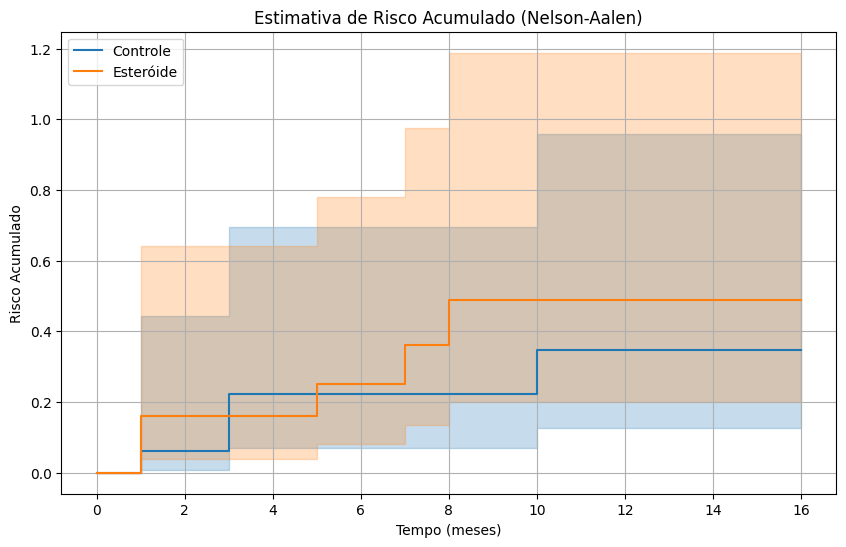

In [6]:
# Estimador de Nelson-Aalen para cada grupo
naf_a = NelsonAalenFitter()
naf_b = NelsonAalenFitter()

# Ajustar os modelos
naf_a.fit(durations=group_a["time"], event_observed=group_a["event"], label="Controle")
naf_b.fit(durations=group_b["time"], event_observed=group_b["event"], label="Esteróide")

# Visualização
plt.figure(figsize=(10, 6))
naf_a.plot_cumulative_hazard(ci_show=True)
naf_b.plot_cumulative_hazard(ci_show=True)
plt.title("Estimativa de Risco Acumulado (Nelson-Aalen)")
plt.xlabel("Tempo (meses)")
plt.ylabel("Risco Acumulado")
plt.grid(True)
plt.show()

###Estimação por Kernell

/tmp/ipython-input-3403331292.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  observed_times_a = group_a[data["event"] == 1]["time"].values #grupo controle
/tmp/ipython-input-3403331292.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  observed_times_b = group_b[data["event"] == 1]["time"].values #grupo esteróide


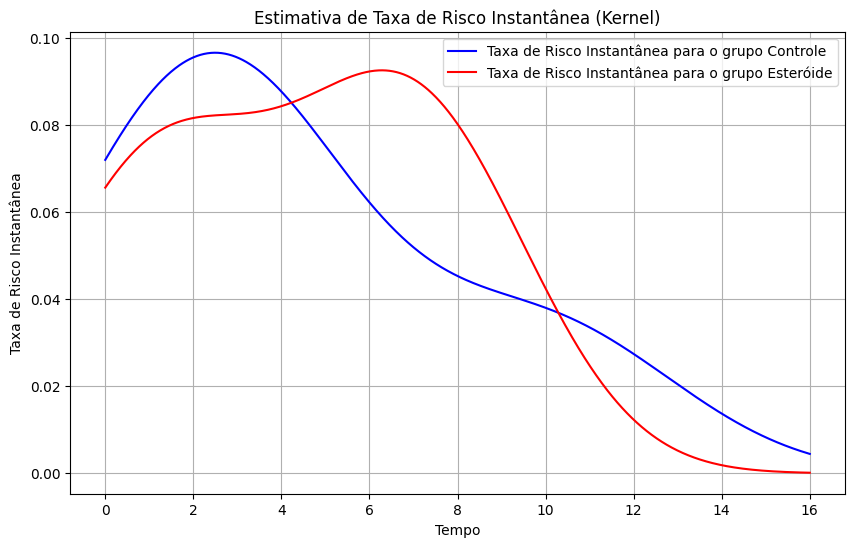

In [7]:
# Filtrar apenas os tempos e eventos observados em cada grupo

observed_times_a = group_a[data["event"] == 1]["time"].values #grupo controle
observed_times_b = group_b[data["event"] == 1]["time"].values #grupo esteróide

# Kernel Density Estimation (Estimador de Kernel)
kde_a = gaussian_kde(observed_times_a, bw_method='scott')  # Suavização automática usando 'scott' grupo controle
kde_b = gaussian_kde(observed_times_b, bw_method='scott')  # Suavização automática usando 'scott' grupo esteróide

# Criar valores de tempo para estimar a densidade
time_grid = np.linspace(0, max(group_a["time"]), 1000)  # Valores entre 0 e o maior tempo

# Calcular a densidade estimada (taxa de risco instantânea)
risk_density_a = kde_a(time_grid)
risk_density_b = kde_b(time_grid)

# Plotar a taxa de risco instantânea
plt.figure(figsize=(10, 6))
plt.plot(time_grid, risk_density_a, label="Taxa de Risco Instantânea para o grupo Controle", color="blue")
plt.plot(time_grid, risk_density_b, label="Taxa de Risco Instantânea para o grupo Esteróide", color="red")
plt.title("Estimativa de Taxa de Risco Instantânea (Kernel)")
plt.xlabel("Tempo")
plt.ylabel("Taxa de Risco Instantânea")
plt.grid(True)
plt.legend()
plt.show()

###Teste de Log-Rank para comparação das curvas de sobrevivência com risco proporcional

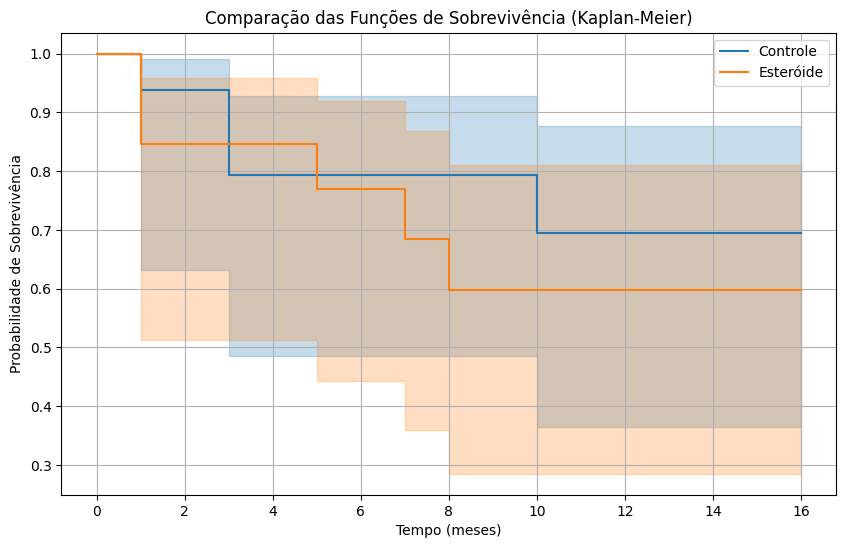

Resultado do Teste de Log-Rank
Estatística do teste: 0.2220
Valor-p: 0.6375
Não rejeitamos a hipótese nula: Não há diferença significativa entre as curvas de sobrevivência.


In [14]:
# Kaplan-Meier para visualização
kmf_a = KaplanMeierFitter()
kmf_b = KaplanMeierFitter()

plt.figure(figsize=(10, 6))
kmf_a.fit(durations=group_a["time"], event_observed=group_a["event"], label="Controle")
kmf_a.plot_survival_function(ci_show=True)
kmf_b.fit(durations=group_b["time"], event_observed=group_b["event"], label="Esteróide")
kmf_b.plot_survival_function(ci_show=True)

plt.title("Comparação das Funções de Sobrevivência (Kaplan-Meier)")
plt.xlabel("Tempo (meses)")
plt.ylabel("Probabilidade de Sobrevivência")
plt.grid(True)
plt.show()

# Teste de Log-Rank
logrank_result = logrank_test(
    group_a["time"], group_b["time"],
    event_observed_A=group_a["event"],
    event_observed_B=group_b["event"]
)

# Exibindo o resultado do teste
print("Resultado do Teste de Log-Rank")
print(f"Estatística do teste: {logrank_result.test_statistic:.4f}")
print(f"Valor-p: {logrank_result.p_value:.4f}")

# Interpretação
if logrank_result.p_value < 0.05:
    print("Rejeitamos a hipótese nula: As curvas de sobrevivência são significativamente diferentes.")
else:
    print("Não rejeitamos a hipótese nula: Não há diferença significativa entre as curvas de sobrevivência.")

###Teste de Wilcoxon para comparar curvas de sobrevivência com risco não proporcional (atribui mais peso aos tempos iniciais)

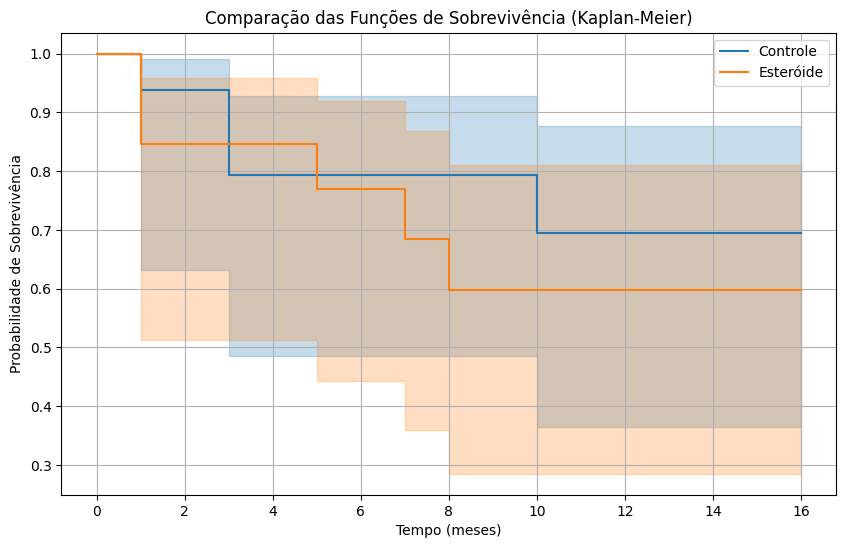

Estatística do teste: 0.2670
p-valor: 0.6054
Resultado: Não rejeita H₀ (sem diferença significativa, p ≥ 0.05)


In [19]:
# Kaplan-Meier para visualização
kmf_a = KaplanMeierFitter()
kmf_b = KaplanMeierFitter()

plt.figure(figsize=(10, 6))
kmf_a.fit(durations=group_a["time"], event_observed=group_a["event"], label="Controle")
kmf_a.plot_survival_function(ci_show=True)
kmf_b.fit(durations=group_b["time"], event_observed=group_b["event"], label="Esteróide")
kmf_b.plot_survival_function(ci_show=True)

plt.title("Comparação das Funções de Sobrevivência (Kaplan-Meier)")
plt.xlabel("Tempo (meses)")
plt.ylabel("Probabilidade de Sobrevivência")
plt.grid(True)
plt.show()

# Teste de Wilcoxon (Breslow)
resultado = logrank_test(
    group_a['time'], group_b['time'],
    event_observed_a=group_a['event'],
    event_observed_b=group_b['event'],
    weightings='wilcoxon'   # <- define o tipo de teste
)

# Extrair valores
estatistica = resultado.test_statistic
p_valor = resultado.p_value

# Imprimir resultado e decisão automática
print(f"Estatística do teste: {estatistica:.4f}")
print(f"p-valor: {p_valor:.4f}")

# Decisão automática
alpha = 0.05
if p_valor < alpha:
    print(f"Resultado: Rejeita H₀ (diferença significativa entre as curvas, p < {alpha})")
else:
    print(f"Resultado: Não rejeita H₀ (sem diferença significativa, p ≥ {alpha})")